# Model Training
Take-Home Test: Fraudulent Transaction Detection

by Sawit Koseeyaumporn

Perform train-test split, data preprocessing, model training, and handle imbalanced datasets for fraud detection on the dataframe `df`.

In [2]:
import pandas as pd

df = pd.read_csv("./data/fraud_mock.csv")
df.head()

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
0,1,PAYMENT,9839.64,acc910286,170136.0,160296.36,acc298089,0.0,0.0,0,0
1,1,PAYMENT,1864.28,acc6597009,21249.0,19384.72,acc8726693,0.0,0.0,0,0
2,1,TRANSFER,181.00,acc1796908,181.0,0.00,acc4938640,0.0,0.0,1,0
3,1,CASH_OUT,181.00,acc4182296,181.0,0.00,acc1221153,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,acc7841596,41554.0,29885.86,acc5599142,0.0,0.0,0,0


## 1. Split data

Split the data into training and testing sets using the specified features and target variable, test size, and random state.


In [ ]:
from sklearn.model_selection import train_test_split

X = df[['time_ind', 'transac_type', 'amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Original data shape: (6362620, 11)
Training data shape: (3817572, 7) (3817572,)
Testing data shape: (1272524, 7) (1272524,)
Unknown data shape: (1272524, 7) (1272524,)


## Feature selection

### Subtask:
Identify relevant features based on the EDA insights.


**Reasoning**:
Based on the EDA, the most informative features are transaction type, amount, and account balance related columns. Update the training and testing DataFrames to include only these features.



In [ ]:
relevant_features = ['transac_type', 'amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']

X_train = X_train[relevant_features]
X_test = X_test[relevant_features]

display(X_train.head())
display(X_test.head())

,transac_type,amount,src_bal,src_new_bal,dst_bal,dst_new_bal
950383,CASH_OUT,28970.24,5043.00,0.0,0.00,28970.24
4726448,CASH_OUT,113276.32,766.00,0.0,1395944.95,1509221.27
812365,PAYMENT,7111.48,0.00,0.0,0.00,0.00
2674942,TRANSFER,380425.14,229653.00,0.0,124339.15,504764.29
5703950,PAYMENT,27822.19,451325.69,423503.5,0.00,0.00


,transac_type,amount,src_bal,src_new_bal,dst_bal,dst_new_bal
2309985,PAYMENT,9795.47,0.00,0.00,0.00,0.00
2526089,CASH_OUT,8212.06,35863.00,27650.94,0.00,8212.06
2018072,PAYMENT,4327.49,743635.84,739308.35,0.00,0.00
3569677,TRANSFER,142407.65,0.00,0.00,830469.20,1181738.48
3508921,CASH_IN,56162.33,10111.00,66273.33,39455.88,0.00


## Categorical feature encoding

### Subtask:
Convert categorical features like `transac_type` into numerical representations using techniques like one-hot encoding.


**Reasoning**:
Apply one-hot encoding to the categorical 'transac_type' column in both training and testing sets and display the first few rows of the encoded dataframes.



In [ ]:
X_train = pd.get_dummies(X_train, columns=['transac_type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['transac_type'], drop_first=True)

# Ensure consistent columns between train and test sets
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols]

display(X_train.head())
display(X_test.head())

,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_CASH_OUT,transac_type_DEBIT,transac_type_PAYMENT,transac_type_TRANSFER
950383,28970.24,5043.00,0.0,0.00,28970.24,True,False,False,False
4726448,113276.32,766.00,0.0,1395944.95,1509221.27,True,False,False,False
812365,7111.48,0.00,0.0,0.00,0.00,False,False,True,False
2674942,380425.14,229653.00,0.0,124339.15,504764.29,False,False,False,True
5703950,27822.19,451325.69,423503.5,0.00,0.00,False,False,True,False


,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_CASH_OUT,transac_type_DEBIT,transac_type_PAYMENT,transac_type_TRANSFER
2309985,9795.47,0.00,0.00,0.00,0.00,False,False,True,False
2526089,8212.06,35863.00,27650.94,0.00,8212.06,True,False,False,False
2018072,4327.49,743635.84,739308.35,0.00,0.00,False,False,True,False
3569677,142407.65,0.00,0.00,830469.20,1181738.48,False,False,False,True
3508921,56162.33,10111.00,66273.33,39455.88,0.00,False,False,False,False


## Feature scaling

### Subtask:
Scale numerical features to ensure they have a similar range, which can improve the performance of some models.


**Reasoning**:
Scale the numerical features in X_train and X_test using StandardScaler and replace the original numerical columns with the scaled values.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding one-hot encoded columns)
numerical_cols_train = X_train.select_dtypes(include=['float64', 'int64']).columns
numerical_cols_test = X_test.select_dtypes(include=['float64', 'int64']).columns

# Assuming the last 4 columns are the one-hot encoded columns based on previous steps
# Adjust this if the number or order of one-hot encoded columns changes
num_encoded_cols = 4
numerical_cols_to_scale_train = numerical_cols_train[:-num_encoded_cols]
numerical_cols_to_scale_test = numerical_cols_test[:-num_encoded_cols]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train[numerical_cols_to_scale_train] = scaler.fit_transform(X_train[numerical_cols_to_scale_train])
X_test[numerical_cols_to_scale_test] = scaler.transform(X_test[numerical_cols_to_scale_test])

# Display the head of the scaled DataFrames
display(X_train.head())
display(X_test.head())

,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_CASH_OUT,transac_type_DEBIT,transac_type_PAYMENT,transac_type_TRANSFER
950383,-0.252516,5043.00,0.0,0.00,28970.24,True,False,False,False
4726448,-0.111130,766.00,0.0,1395944.95,1509221.27,True,False,False,False
812365,-0.289174,0.00,0.0,0.00,0.00,False,False,True,False
2674942,0.336895,229653.00,0.0,124339.15,504764.29,False,False,False,True
5703950,-0.254441,451325.69,423503.5,0.00,0.00,False,False,True,False


,amount,src_bal,src_new_bal,dst_bal,dst_new_bal,transac_type_CASH_OUT,transac_type_DEBIT,transac_type_PAYMENT,transac_type_TRANSFER
2309985,-0.284673,0.00,0.00,0.00,0.00,False,False,True,False
2526089,-0.287329,35863.00,27650.94,0.00,8212.06,True,False,False,False
2018072,-0.293843,743635.84,739308.35,0.00,0.00,False,False,True,False
3569677,-0.062275,0.00,0.00,830469.20,1181738.48,False,False,False,True
3508921,-0.206913,10111.00,66273.33,39455.88,0.00,False,False,False,False


## Handle imbalance

### Subtask:
Address the class imbalance issue using appropriate techniques such as oversampling (e.g., SMOTE) or undersampling on the training data.


**Reasoning**:
Apply SMOTE to the training data to address the class imbalance and then display the class distribution of the resampled data.



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution in original training data:")
print(y_train.value_counts())
print("\nClass distribution in resampled training data:")
print(y_train_resampled.value_counts())

Class distribution in original training data:
is_fraud
0    3812625
1       4947
Name: count, dtype: int64

Class distribution in resampled training data:
is_fraud
0    3812625
1    3812625
Name: count, dtype: int64


## Model selection and training

### Subtask:
Choose a suitable model for fraud detection (e.g., Logistic Regression, Random Forest, Gradient Boosting, or a more advanced technique like a neural network) and train it on the preprocessed training data.


**Reasoning**:
Import a suitable classification model (RandomForestClassifier) and train it on the resampled training data with balanced class weights.



In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)

model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Data preprocessing
Model selection and training
Model evaluation
Hyperparameter tuning
Prediction and interpretation
Finish task

## Model evaluation

### Subtask:
Evaluate the trained model's performance on the testing set using appropriate metrics for imbalanced datasets (e.g., Precision, Recall, F1-score, AUC-ROC).

**Reasoning**:
Evaluate the trained XGBoost model on the test set using classification report and confusion matrix to assess its performance, particularly focusing on precision, recall, and F1-score for the minority class (fraudulent transactions) due to the class imbalance.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270928
           1       0.39      0.99      0.56      1596

    accuracy                           1.00   1272524
   macro avg       0.69      0.99      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:


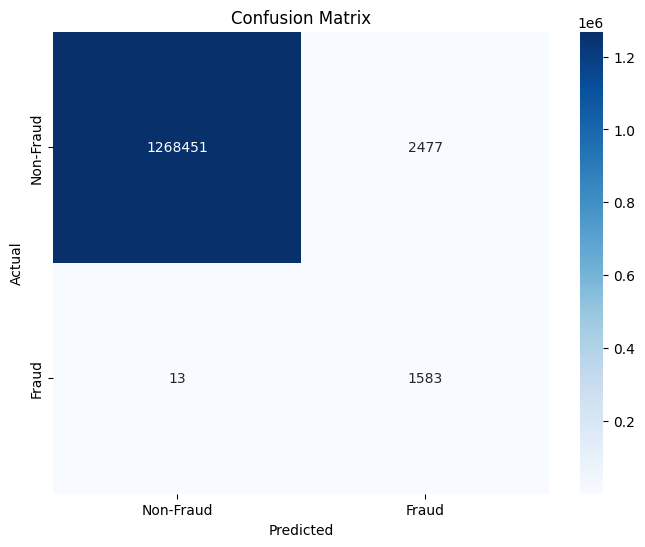


AUC-ROC Score:
AUC-ROC: 0.9991


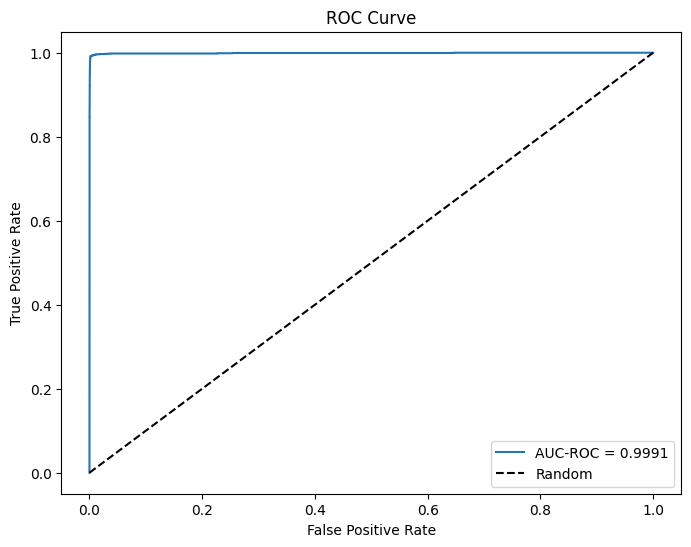

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nAUC-ROC Score:")
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC-ROC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Task
Visualize the clustering of 'TRANSFER' and 'CASH_OUT' transactions based on numerical features using dimensionality reduction (t-SNE or UMAP) and color the points by the `is_fraud` column.

## Filter data

### Subtask:
Filter the original DataFrame to include only 'TRANSFER' and 'CASH_OUT' transaction types.


**Reasoning**:
Filter the original DataFrame to include only 'TRANSFER' and 'CASH_OUT' transaction types and display the head and shape of the filtered DataFrame.



In [ ]:
df_filtered = df[df['transac_type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

display(df_filtered.head())
print("\nShape of the filtered DataFrame:")
print(df_filtered.shape)

,time_ind,transac_type,amount,src_acc,src_bal,src_new_bal,dst_acc,dst_bal,dst_new_bal,is_fraud,is_flagged_fraud
2,1,TRANSFER,181.00,acc1796908,181.0,0.0,acc4938640,0.0,0.00,1,0
3,1,CASH_OUT,181.00,acc4182296,181.0,0.0,acc1221153,21182.0,0.00,1,0
15,1,CASH_OUT,229133.94,acc7697333,15325.0,0.0,acc2123864,5083.0,51513.44,0,0
19,1,TRANSFER,215310.30,acc8579790,705.0,0.0,acc1511007,22425.0,0.00,0,0
24,1,TRANSFER,311685.89,acc5249602,10835.0,0.0,acc5114175,6267.0,2719172.89,0,0



Shape of the filtered DataFrame:
(2770409, 11)


## Feature selection and preprocessing

### Subtask:
Select relevant numerical features and potentially apply scaling. Since categorical features are already filtered, focus on numerical ones.


In [ ]:
from sklearn.preprocessing import StandardScaler

X_numerical = df_filtered[['amount', 'src_bal', 'src_new_bal', 'dst_bal', 'dst_new_bal']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numerical)

y_filtered = df_filtered['is_fraud']

print("Shape of scaled numerical features:")
print(X_scaled.shape)
print("\nShape of filtered target variable:")
print(y_filtered.shape)

Shape of scaled numerical features:
(2770409, 5)

Shape of filtered target variable:
(2770409,)


## Dimensionality reduction

### Subtask:
Apply a dimensionality reduction technique like t-SNE or UMAP to reduce the selected features to 2 components for visualization.


**Reasoning**:
Apply UMAP dimensionality reduction to the scaled numerical features to reduce them to 2 components for visualization.



**Reasoning**:
The previous command failed because the dataframe 'df' was not defined. Load the dataframe 'df' from the csv file, then filter the data, apply dimensionality reduction, and finally create the scatter plot.



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


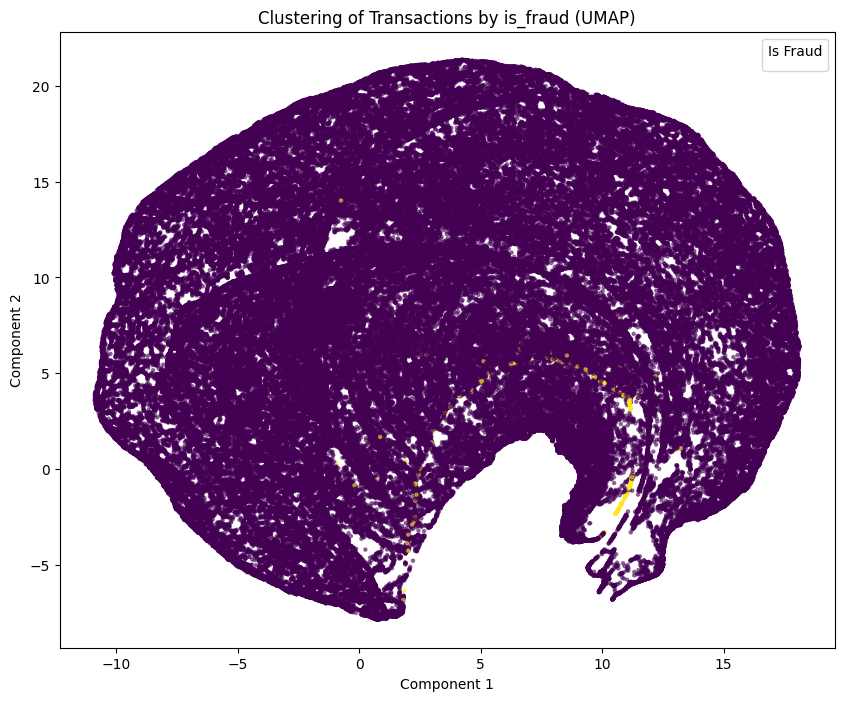